In [75]:
from TC import TC
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [76]:
CATEGORICAL_FILE = r"../data/drug_consumption_transformed.csv"

PRED_CAT_FILE = r"../data/nb/pred_cat.csv"
PRED_NUM_FILE = r"../data/nb/pred_num.csv"

OUTPUT_CAT_PLOT = r"../plots/nb_TC_cat.png"
OUTPUT_NUM_PLOT = r"../plots/nb_TC_num.png"

In [77]:
pred_cat

array([[6., 6., 6., ..., 6., 4., 5.],
       [6., 6., 6., ..., 6., 4., 5.],
       [6., 6., 6., ..., 6., 4., 5.],
       ...,
       [6., 6., 6., ..., 6., 6., 6.],
       [6., 6., 6., ..., 6., 6., 6.],
       [6., 6., 5., ..., 6., 6., 6.]], shape=(161, 1885))

In [78]:
df_cat = pd.read_csv(CATEGORICAL_FILE)
true_values = df_cat["choc"].str[2].astype(int)

n = len(true_values)
alphas = 10**np.arange(-4,4.05,0.05)
alphas_log10 = np.log10(alphas)

pred_cat = np.loadtxt(PRED_CAT_FILE, delimiter = ",")
pred_num = np.loadtxt(PRED_NUM_FILE, delimiter = ",")

In [79]:
confusion_cat = np.apply_along_axis(confusion_matrix, 1, pred_cat, true_values)
confusion_num = np.apply_along_axis(confusion_matrix, 1, pred_num, true_values)

TC_cat = np.array([TC(C) for C in confusion_cat])
TC_num = np.array([TC(C) for C in confusion_num])

In [80]:
confusion_cat[0], confusion_cat[37], confusion_cat[80]

(array([[  0,   0,   0,   0,   0,   2,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   1,   1],
        [  6,   1,   1,   6,  70, 112, 105],
        [  6,   1,   4,  13,  90, 129, 139],
        [ 20,   1,   5,  35, 136, 439, 562]]),
 array([[  0,   0,   0,   0,   0,   2,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   1,   1],
        [  6,   1,   1,   6,  70, 112, 105],
        [  6,   1,   4,  13,  90, 129, 139],
        [ 20,   1,   5,  35, 136, 439, 562]]),
 array([[  0,   0,   0,   0,   1,   3,   0],
        [  0,   0,   0,   0,   0,   0,   1],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   1,   1],
        [  6,   1,   1,   6,  69, 108,  97],
        [  6,   1,   4,  13,  89, 129, 142],
        [ 20,   1,   5,  35, 137, 442, 566]]))

In [81]:
min_TC_cat = TC_cat.min()
min_index_cat = np.argmin(TC_cat)
min_alpha_cat = alphas[min_index_cat]

min_TC_num = TC_num.min()
min_index_num = np.argmin(TC_num)
min_alpha_num = alphas[min_index_num]

In [86]:
confusion_cat[min_index_cat], confusion_num[min_index_num]

(array([[  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   1,   1,   2,   7,   4],
        [  6,   2,   1,  12,  73, 108, 117],
        [ 26,   1,   8,  41, 221, 568, 686]]),
 array([[  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   1,   1,   3,   8,   8],
        [  5,   1,   2,  11,  82, 122, 114],
        [ 27,   2,   7,  42, 211, 553, 685]]))

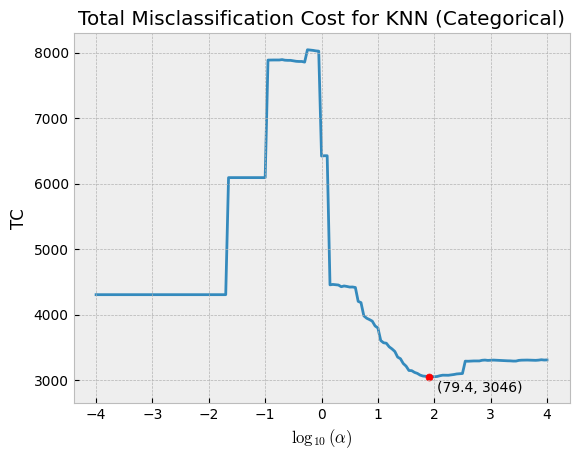

In [147]:
plt.style.use("bmh")
plt.plot(alphas_log10, TC_cat, zorder = 0)
plt.xlabel(r"$\log_{10}(\alpha)$")
plt.ylabel("TC")
plt.ylim(2650, 8300)
plt.title("Total Misclassification Cost for KNN (Categorical)")
plt.scatter(np.log10(min_alpha_cat), min_TC_cat, color = "red", zorder = 1, s = 25)
plt.annotate((min_alpha_cat.round(1).item(), int(min_TC_cat)), xy=(np.log10(min_alpha_cat), min_TC_cat), xytext=(np.log10(min_alpha_cat)+0.15, min_TC_cat-230))

plt.savefig(OUTPUT_CAT_PLOT, dpi = 300)
plt.show()

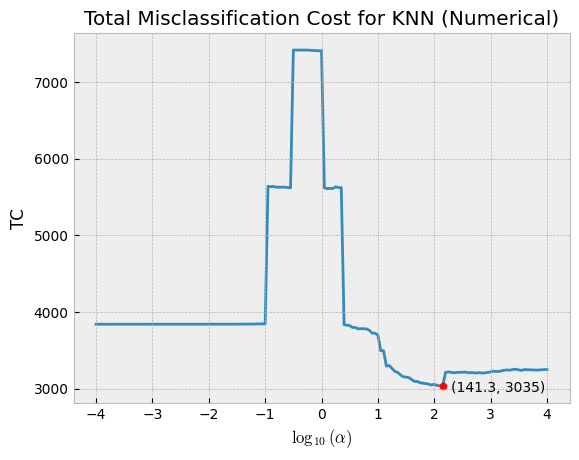

In [126]:
plt.style.use("bmh")
plt.plot(alphas_log10, TC_num, zorder = 0)
plt.xlabel(r"$\log_{10}(\alpha)$")
plt.ylabel("TC")
plt.title("Total Misclassification Cost for KNN (Numerical)")
plt.scatter(np.log10(min_alpha_num), min_TC_num, color = "red", zorder = 1, s = 25)
plt.annotate((min_alpha_num.round(1).item(), int(min_TC_num)), xy=(np.log10(min_alpha_num), min_TC_num), xytext=(np.log10(min_alpha_num)+0.15, min_TC_num-80))

plt.savefig(OUTPUT_NUM_PLOT, dpi = 300)
plt.show()